# Task 2: The Solow model with a time-varying savings rate 

In [1]:
# Setup 
from SolowModel import SolowModelClass
import numpy as np
import matplotlib.pyplot as plt

model = SolowModelClass()
print(model)

Solow model with:
  alpha = 0.3333 (capital share)
  delta = 0.3000 (depreciation rate)
  s_bar = 0.2500 (long-run savings rate)
  beta  = 0.8333 (discount factor)
  k0    = 0.1000 (initial capital per worker)
  T     = 100 (number of periods)


### Task 2.1: Steady state and baseline simulation

We first compute the analytical steady state and confirm it numerically with a root-finder. We then simulate the model with a constant savings rate as our baseline. 

In [2]:
# a. analytical and numerical steady state
k_star, y_star, c_star = model.steady_state()
k_star_numerical = model.solve_steady_state()

print(f'k* (analytical) = {k_star:.4f}')
print(f'k* (numerical)  = {k_star_numerical:.4f}')
print(f'y* = {y_star:.4f}')
print(f'c* = {c_star:.4f}')

k* (analytical) = 0.7607
k* (numerical)  = 0.7607
y* = 0.9129
c* = 0.6847


The analytical and numerical steady-state values for k* both equal 0.7607, confirming that the root-finder correctly identifies the fixed point of the law of motion (4)

### Baseline simulation

We simulate the model for T periods with a constant savings rate s_t = s̄, starting from k₀ = 0.10

In [3]:
from copy import deepcopy

# b. simulate the baseline (constant savings rate)
sim_baseline = deepcopy(model.simulate(model.par.s_bar))

print(f'c0    = {sim_baseline.c[0]:.4f}')
print(f'c_T-1 = {sim_baseline.c[-1]:.4f}')
print(f'k_T-1 = {sim_baseline.k[-1]:.4f}')

c0    = 0.3481
c_T-1 = 0.6847
k_T-1 = 0.7607


### Figure: Baseline paths 

We plot the savings rate, capital, and consumption per worker over time.

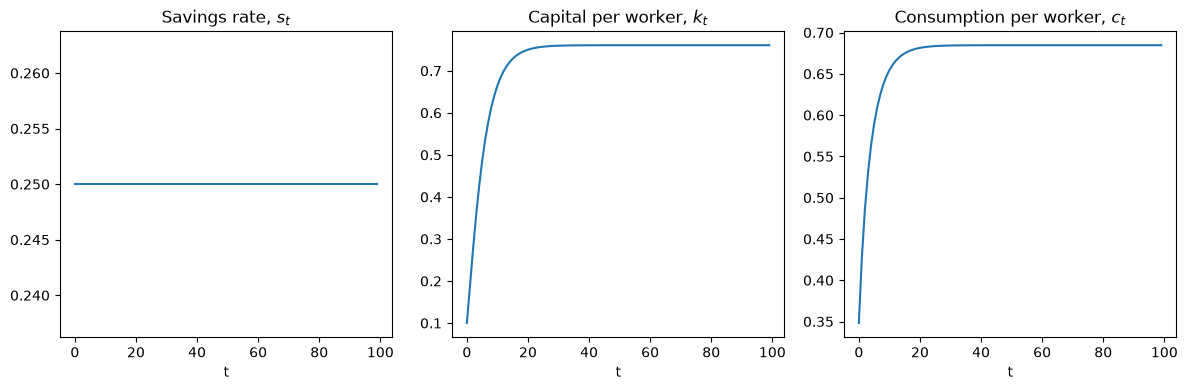

In [4]:
# c. plot the baseline paths
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(sim_baseline.s)
axes[0].set_title('Savings rate, $s_t$')
axes[0].set_xlabel('t')

axes[1].plot(sim_baseline.k)
axes[1].set_title('Capital per worker, $k_t$')
axes[1].set_xlabel('t')

axes[2].plot(sim_baseline.c)
axes[2].set_title('Consumption per worker, $c_t$')
axes[2].set_xlabel('t')

fig.tight_layout()
plt.show()

As expected, capital and consumption per worker converge monotonically towards their steady-state values, while the savings rate stays constant at s̄ = 0.25.

### Sanity checks

we verify the simulator with two checks: An economy starting at k* should remain there, and an economy with s = 0 should have capital decaying at rate (1-δ) each period. 

In [5]:
# d. sanity checks
# Check 1: an economy starting in steady state stays there
k_star, _, _ = model.steady_state()
sim_check1 = model.simulate(model.par.s_bar, k0=k_star)
assert np.allclose(sim_check1.k, k_star), 'capital should stay at k* when starting there'

# Check 2: with s = 0, capital decays as k_t = (1-delta)^t * k0
sim_check2 = model.simulate(0.0, k0=model.par.k0)
t = np.arange(model.par.T)
k_theory = (1 - model.par.delta)**t * model.par.k0
assert np.allclose(sim_check2.k, k_theory), 'capital should decay at rate (1-delta) with s=0'

print('Both sanity checks passed.')

Both sanity checks passed.


### Task 2.2: The time-varying savings rule

We implement the savings rule s_t = s̄ + (s0 - s̄)φ^t in 's_path', and simulate the model for four combinations of (s0, φ), together with the baseline. 

In [6]:
# a. implement and test s_path
s_test = model.s_path(s0=0.30, phi=0.50)
print(f's_0  = {s_test[0]:.4f} (should be 0.30)')
print(f's_1  = {s_test[1]:.4f}')
print(f's_99 = {s_test[-1]:.4f} (should be close to s_bar = 0.25)')

s_0  = 0.3000 (should be 0.30)
s_1  = 0.2750
s_99 = 0.2500 (should be close to s_bar = 0.25)


### Simulating the four combinations 

We simulate the four (s0, φ) combinations together with the baseline, and plot s_t, k_t and c_t for all five paths. 

In [7]:
# b. simulate the four combinations
combinations = [(0.30, 0.50), (0.40, 0.80), (0.10, 0.50), (0.60, 0.60)]

sims = {}
sims['baseline'] = sim_baseline

for s0, phi in combinations:
    s_vec = model.s_path(s0, phi)
    sims[(s0, phi)] = deepcopy(model.simulate(s_vec))

for key, sim in sims.items():
    print(f'{key}: k_T-1 = {sim.k[-1]:.4f}')

baseline: k_T-1 = 0.7607
(0.3, 0.5): k_T-1 = 0.7607
(0.4, 0.8): k_T-1 = 0.7607
(0.1, 0.5): k_T-1 = 0.7607
(0.6, 0.6): k_T-1 = 0.7607


All five k_T - 1 values are identical (0.7607). This is because every rule has φ < 1, so s_t converges back to s̄ over time, and with T=100 periods there is ample time for capital to reach the same long-run steady state regardless of the initial savings rate. Only the transition path differs between the rules, not the final destination. 

### Figure: all five paths compared

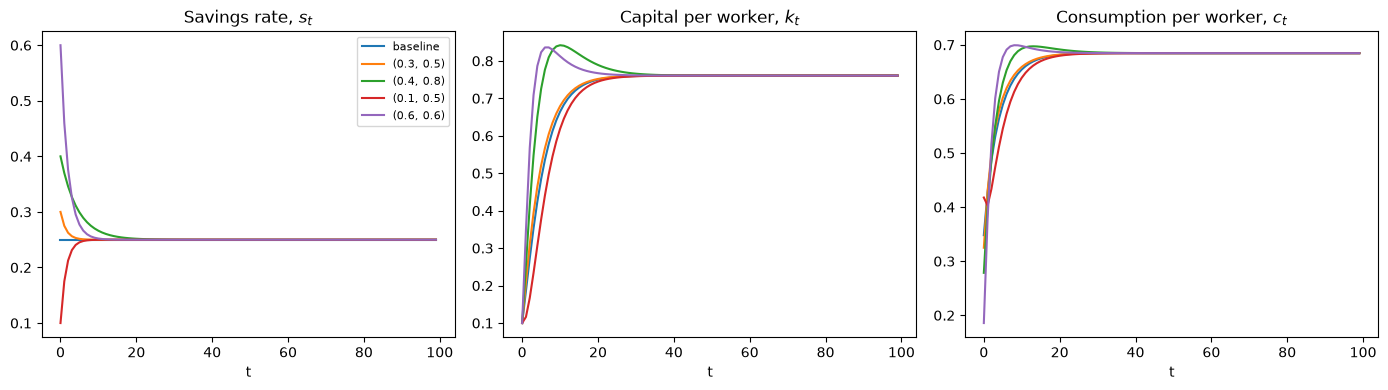

In [8]:
# c. plot all five paths together
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for key, sim in sims.items():
    axes[0].plot(sim.s, label=str(key))
    axes[1].plot(sim.k, label=str(key))
    axes[2].plot(sim.c, label=str(key))

axes[0].set_title('Savings rate, $s_t$')
axes[1].set_title('Capital per worker, $k_t$')
axes[2].set_title('Consumption per worker, $c_t$')
for ax in axes: ax.set_xlabel('t')

axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

A higher s0 gives an overshoot in capital and consumption before they settle down again. A lower s0 gives a dip first, then recovery. φ controls the speed: low φ means the savings rate goes back to s̄ fast, high φ means it stays high/low for longer. 

### Task 2.3: welfare

We compute W for the baseline and the four rules, and compare each to the baseline. 

In [9]:
# a. welfare of the baseline and the four combinations
W_baseline = model.welfare(sim_baseline.c)

results = {'baseline': W_baseline}
for s0, phi in combinations:
    results[(s0, phi)] = model.welfare(sims[(s0, phi)].c)

print(f'{"rule":<15}{"W":>10}{"W - W_baseline":>18}')
for key, W in results.items():
    print(f'{str(key):<15}{W:>10.4f}{W - W_baseline:>18.4f}')

rule                    W    W - W_baseline
baseline          -3.9944            0.0000
(0.3, 0.5)        -3.9857            0.0087
(0.4, 0.8)        -4.0914           -0.0970
(0.1, 0.5)        -4.1460           -0.1516
(0.6, 0.6)        -4.3407           -0.3463


Only (0.3, 0.5) beats the baseline. The others give lower welfare, even though capital ends up the same for all of them. This is because welfare cares about the whole consumption path, not just the end point, starting with a high s0 means less consumption, and that hurts W since early consumption counts more (discounting with beta). You couldn't really tell this from the figure alone, since all the paths end at the same k_T - 1, but W picks up the differences in how they get there. 

### Task 2.4: Finding the best rule

### Grid search

We compute W on a grid over s0 and φ, and find the best point on the grid.

s0  = 0.3061
phi = 0.2327
W   = -3.9844


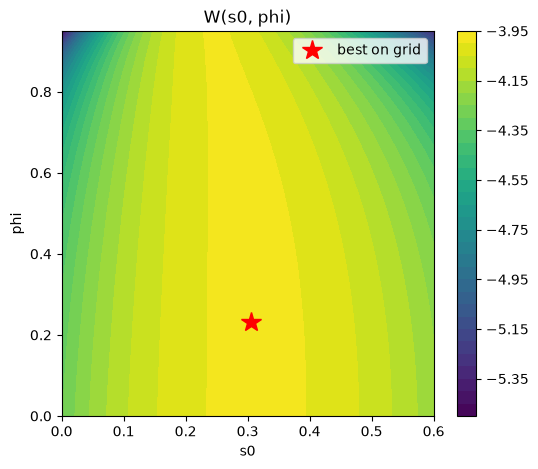

In [10]:
# a. grid search
s0_grid = np.linspace(0, 0.60, 50)
phi_grid = np.linspace(0, 0.95, 50)

W_grid = np.empty((len(s0_grid), len(phi_grid)))
for i, s0 in enumerate(s0_grid):
    for j, phi in enumerate(phi_grid):
        W_grid[i, j] = model.evaluate(s0, phi)

# find the best point on the grid
i_best, j_best = np.unravel_index(np.argmax(W_grid), W_grid.shape)
s0_best_grid = s0_grid[i_best]
phi_best_grid = phi_grid[j_best]
W_best_grid = W_grid[i_best, j_best]

print(f's0  = {s0_best_grid:.4f}')
print(f'phi = {phi_best_grid:.4f}')
print(f'W   = {W_best_grid:.4f}')

#plot 
S0, PHI = np.meshgrid(s0_grid, phi_grid, indexing='ij')
fig, ax = plt.subplots(figsize=(6,5))
cs = ax.contourf(S0, PHI, W_grid, levels=30)
ax.plot(s0_best_grid, phi_best_grid, 'r*', markersize=15, label='best on grid')
ax.set_xlabel('s0')
ax.set_ylabel('phi')
ax.set_title('W(s0, phi)')
fig.colorbar(cs)
ax.legend()
plt.show()


### Numerical optimization 

We use the best grid point as starting guess and run a numerical optimizer to refine it.

In [11]:
# b. numerical optimization 
from scipy import optimize

obj = lambda x: -model.evaluate(x[0], x[1])  # negative because we minimize
x0 = [s0_best_grid, phi_best_grid]

result = optimize.minimize(obj, x0, method='Nelder-Mead')

s0_best, phi_best = result.x
W_best = -result.fun

print(f's0  = {s0_best:.4f} (grid: {s0_best_grid:.4f})')
print(f'phi = {phi_best:.4f} (grid: {phi_best_grid:.4f})')
print(f'W   = {W_best:.4f} (grid: {W_best_grid:.4f})')

s0  = 0.3115 (grid: 0.3061)
phi = 0.2207 (grid: 0.2327)
W   = -3.9843 (grid: -3.9844)


The optimizer barely improves on the grid point (W goes from -3.9844 to -3.9843). Makes sense since the grid already had 50x50 points and landed close to the true optimum. The surface also look pretty flat around there in the countour plot, so there isn't much left to gain. 

### Best rule vs baseline 

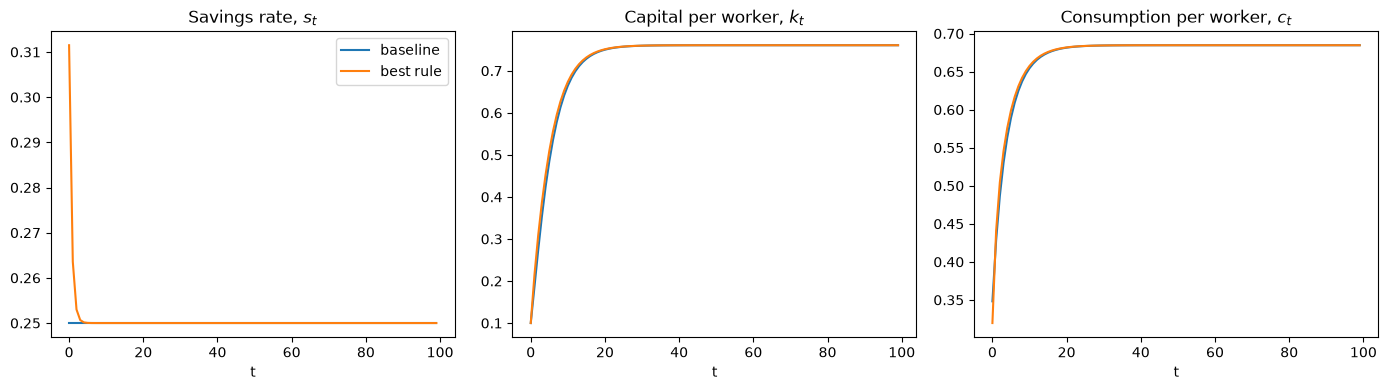

c0 (best rule) = 0.3196
c0 (baseline)  = 0.3481
first period where c_t (best) > c_t (baseline): t = 1


In [12]:
# c. simulate and plot the best rule 
s_best_vec = model.s_path(s0_best, phi_best)
sim_best = deepcopy(model.simulate(s_best_vec))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(sim_baseline.s, label='baseline')
axes[0].plot(sim_best.s, label='best rule')
axes[1].plot(sim_baseline.k, label='baseline')
axes[1].plot(sim_best.k, label='best rule')
axes[2].plot(sim_baseline.c, label='baseline')
axes[2].plot(sim_best.c, label='best rule')

axes[0].set_title('Savings rate, $s_t$')
axes[1].set_title('Capital per worker, $k_t$')
axes[2].set_title('Consumption per worker, $c_t$')
for ax in axes: ax.set_xlabel('t')
axes[0].legend()

fig.tight_layout()
plt.show()

# report c0 and first period where c_t exceeds baseline 
c0_best = sim_best.c[0]
first_above = np.argmax(sim_best.c > sim_baseline.c)

print(f'c0 (best rule) = {c0_best:.4f}')
print(f'c0 (baseline)  = {sim_baseline.c[0]:.4f}')
print(f'first period where c_t (best) > c_t (baseline): t = {first_above}')

c0 is lower for the best rule than the baseline (0.3196 vs 0.3481), since s0 ≈ 0.31 is higher than s̄, so more gets saved and less consumed at first. But it only takes one period before consumption overtakes the baseline, after that the extra capital pays off. 

### Task 2.5: Three-parameter rule

Now s_inf is also free instead of fixed at s̄. We optimize over all three parameters.

In [13]:
# a. optimize over (s0, phi, s_inf)
obj3 = lambda x: -model.evaluate3(x[0], x[1], x[2])
x0_3 = [s0_best, phi_best, model.par.s_bar]
result3 = optimize.minimize(obj3, x0_3, method='Nelder-Mead')
s0_best3, phi_best3, s_inf_best3 = result3.x
W_best3 = -result3.fun
print(f's0    = {s0_best3:.4f}')
print(f'phi   = {phi_best3:.4f}')
print(f's_inf = {s_inf_best3:.4f}')
print(f'W     = {W_best3:.4f}')
print(f'improvement over Q4: {W_best3 - W_best:.4f}')

s0    = 0.3139
phi   = 0.6709
s_inf = 0.1989
W     = -3.9670
improvement over Q4: 0.0173


In [14]:
# b. compare K_T - 1 with k* from question 1
s_best3_vec = model.s_path3(s0_best3, phi_best3, s_inf_best3)
sim_best3 = deepcopy(model.simulate(s_best3_vec))

print(f'k_T-1 (best 3-param rule) = {sim_best3.k[-1]:.4f}')
print(f'k* (from Q1)              = {k_star:.4f}')

k_T-1 (best 3-param rule) = 0.5400
k* (from Q1)              = 0.7607


k_T - 1 for the best three parameter rule is not the same as k* from question 1 (0.5400 vs 0.7607). That confirms what we expected, since s_inf ends up around 0.20 instead of s_bar at 0.25. Capital converges to a lower steady state because the long run savings rate is actually lower than in the baseline. 

### Task 2.6: An alternative functional form 

We propose an exponential decay rule s_t = s_bar + (s0 - s_bar) * exp(minus lambda times t) as an alternative to the original power decay rule. It has the same basic shape, starting at s0 and settling at s_bar, but with a different transition curve. 

In [15]:
# a. optimize over (s0, lam)
obj_alt = lambda x: -model.evaluate_alt(x[0], x[1])
x0_alt = [s0_best, 0.2]

result_alt = optimize.minimize(obj_alt, x0_alt, method='Nelder-Mead')
s0_best_alt, lam_best_alt = result_alt.x
W_best_alt = -result_alt.fun

print(f's0    = {s0_best_alt:.4f}')
print(f'lam   = {lam_best_alt:.4f}')
print(f'W     = {W_best_alt:.4f}')

s0    = 0.3115
lam   = 1.5107
W     = -3.9843


In [16]:
# b. summary table comparing Q4, Q5 and Q6
print(f'{"rule":<25}{"W":>10}')
print(f'{"Q4 two parameter":<25}{W_best:>10.4f}')
print(f'{"Q5 three parameter":<25}{W_best3:>10.4f}')
print(f'{"Q6 exponential decay":<25}{W_best_alt:>10.4f}')

rule                              W
Q4 two parameter            -3.9843
Q5 three parameter          -3.9670
Q6 exponential decay        -3.9843


The exponential decay rule from Q6 gives almost the same welfare as the two parameter power rule from Q4, so it does not beat the numbers we found there. The three parameter rule from Q5 is still the best of the three, since letting s_inf be free gives more room to improve welfare than just changing the shape of the transition. 